In [1]:
# importing Necessary Libraries:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

from sklearn.base import BaseEstimator, TransformerMixin

#### Data:

Importing Both Train and Test Data:
- Here, We are importing Both Train and Test Data.
- We will do Data Cleaning, EDA, Needed Feature Transformations on Training Data and Use Training Data to Build and Evaluate Model(s).
- At the end, We will use Test Data, apply same transformation steps on data as on Training Data and Use Model to Predict Target Variable.

In [2]:
# Trainig Data: For Data Cleaning, EDA, Feature Transformations, Model Training and Model Evaluations:
train_df = pd.read_csv('bigmart_train.csv')

# Test Data: To make Predictions Using Built Model:
test_df = pd.read_csv('bigmart_test.csv')

In [3]:
print(train_df.shape)
print(test_df.shape)

(8523, 12)
(5681, 11)


In [4]:
print(train_df.columns)
print(test_df.columns)

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type'],
      dtype='object')


#### Data Cleaning:

In [5]:
train_df.head(7)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528


- Data has both Numerical (Continuous) and Categprical Features.

In [6]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


- Some Numercial Variable like Item Weight have missing values.
- Some variables like Item Visisbility, Item MRP, Item Outlet Sales seems to have Right Skewed Distribution (Due to Maximum value being too far from 75% Percentile Value) and possibly presense of Outliers.
- Outlet Establishment Year can be used to calculate Age of The Outlet.

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
# Missing Values Check:

train_df.isnull().sum() / len(train_df) * 100

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

- Item Weight (Numerical, Continuous) has 17.16% Missing Values.
- Outlet Size (Categorical, Ordinal) has 28.27% Missing Values.

##### 1) Handling Missing Values:

###### 1. Item Weight:

In [9]:
train_df['Item_Weight']

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

In [10]:
train_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


- We should Check how strongly Item Weight Feature is correlated with other Item Related Features.
- Some of the Item Related Features are Categorical in Nature, which needs to be converted in Numerical for calculating Correlations with item Weight.

In [11]:
# Item Identifier:

train_df['Item_Identifier'].value_counts()

Item_Identifier
FDW13    10
FDG33    10
NCY18     9
FDD38     9
DRE49     9
         ..
FDY43     1
FDQ60     1
FDO33     1
DRF48     1
FDC23     1
Name: count, Length: 1559, dtype: int64

- We can Convert This Item identifiers Values to FD (Food), DR (Drink) and NC (Non-Consumable) Categories and Map them to Numericals.

In [12]:
train_df['Item_Identifier'].apply(lambda x: x[:2]).map({'FD': 0, 'DR': 1, 'NC': 2}).value_counts()

Item_Identifier
0    6125
2    1599
1     799
Name: count, dtype: int64

In [13]:
# Item Fat Content:

train_df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

- Low Fat and Regular have Multiple Represenations in Data.
- We can map them to single value.

In [14]:
train_df['Item_Fat_Content'].map({'Low Fat': 0,
                                  'LF': 0, 
                                  'low fat': 0, 
                                  'reg': 1,
                                 'Regular': 1}).value_counts()

Item_Fat_Content
0    5517
1    3006
Name: count, dtype: int64

In [15]:
# Item Type:

train_df['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

- We can use Simple Label Encoder here to convert each value to a numeric represenation.

In [16]:
# Function to Calculate Correlation of Item Weight to Other Item Related Features:

def item_w_corr(df):
    """
    Function to Change Categorical Item Related Features to Numericals and find Correlation of Item Weight Feature to other
    Item Related Features.
    """

    df = df.copy()

    df['Item_Identifier'] = df['Item_Identifier'].apply(lambda x: x[:2]).map({'FD': 0, 'DR': 1, 'NC': 2})
    df['Item_Fat_Content'] = df['Item_Fat_Content'].map({'Low Fat': 0,
                                  'LF': 0, 
                                  'low fat': 0, 
                                  'reg': 0,
                                 'Regular': 1})

    le = LabelEncoder()
    df['Item_Type'] = le.fit_transform(df['Item_Type'])

    sub_df = df[['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP']]

    corr_matrix = sub_df.corr()
    print(corr_matrix['Item_Weight'])

In [17]:
item_w_corr(train_df)

Item_Identifier     0.030399
Item_Weight         1.000000
Item_Fat_Content   -0.023375
Item_Visibility    -0.014048
Item_Type           0.030765
Item_MRP            0.027141
Name: Item_Weight, dtype: float64


As Item Weight has No Significant Correlation with any of The Item Related Features, we will Impute Missing Values with Mean or Median Depending on Distribution of the feature.

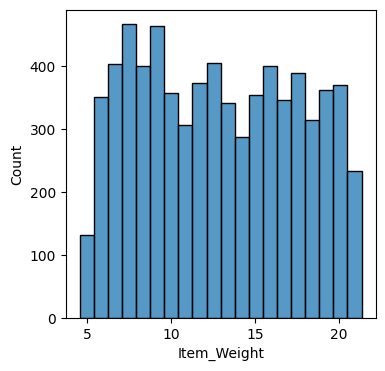

In [18]:
plt.figure(figsize= (4,4))
sns.histplot(data= train_df, x= 'Item_Weight')
plt.show()

- Distribution looks fairly Uniform.
- We can use Mean Imputation to handle Missing Values.
- Item Weight Feature will not require any kind of Transformations too.

**Dictionary to keep Track of Feature Wise Imputation Strategies and Transformations.**

dict = {
    
    'feature1' : {'imputer': 'mean', 'transform': 'log'},
    
    'feature2' : {'imputer': 'median', 'encoder': 'OneHot'}
}

In [19]:
preprocessing_dict = {
    'Item_Weight' : {'imputer': 'mean'}
}

###### 2) Outlet Size:

In [20]:
train_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


- We will check Correlation of Outlet Size to other Outlet Related features.

In [21]:
# Outlet Identifier:

train_df['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64

- We can Use Simple Label Encoder To Change Outlet Identifiers to Numerical feature.

In [22]:
# Outlet Establishment Year:

train_df['Outlet_Establishment_Year'].value_counts()

Outlet_Establishment_Year
1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: count, dtype: int64

- We can change Outlet Establishment Year to Outlet Age.

In [23]:
# Outlet Size:

train_df['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

-  We can use Simple Label Encoder to Change This into Numerical Data.

In [24]:
# Outlet Location Type:

train_df['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

-  We can use Simple Label Encoder to Change This into Numerical Data.

In [25]:
# Outlet Type:

train_df['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

-  We can use Simple Label Encoder to Change This into Numerical Data.

In [26]:
# Function to Calculate Correlation of Outlet Size to other Outlet Related Fields:

def outlet_size_corr(df):
    """
    Function to Change Categorical Outlet Related Features to Numericals and find Correlation of Outlet Size Feature to other
    Outlet Related Features.
    """

    df = df.copy()

    df['Outlet_Age'] = datetime.now().year - df['Outlet_Establishment_Year']

    for col in ['Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

    sub_df = df[['Outlet_Identifier','Outlet_Age', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales']]

    corr_matrix = sub_df.corr()
    print(corr_matrix['Outlet_Size'])

In [27]:
outlet_size_corr(train_df)

Outlet_Identifier       0.053224
Outlet_Age             -0.470343
Outlet_Size             1.000000
Outlet_Location_Type   -0.290216
Outlet_Type            -0.432062
Item_Outlet_Sales      -0.172477
Name: Outlet_Size, dtype: float64


- As Outlet Size has Significant Correlations with Outlet Age and Outlet Type, we will Use Group Based Median to Impute Missing Values in Outlet Size.

In [28]:
# Group based Median Imputer for Outlet Size:

class Outlet_Size_Imputer(BaseEstimator, TransformerMixin):

    def __init__(self, group_cols, target_col):
        self.group_cols = group_cols
        self.target_col = target_col
        self.group_modes_ = None

    def fit(self, X, y= None):
        X_ = X.copy() # Dataframe Copy to avoid mutation

        # Computing Mode of Target Column within Each Group:
        self.group_modes_ = (
            X_.groupby(self.group_cols)[self.target_col].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan).to_dict()
        )

        return self

    def transform(self, X):
        X_ = X.copy()

        # Filling Missing Values based on Group Modes
        for idx, row in X_.loc[X_[self.target_col].isna()].iterrows():
            group_key = tuple(row[col] for col in self.group_cols)
            if group_key in self.group_modes_:
                X_.at[idx, self.target_col] = self.group_modes_[group_key]

         # Fallback: fill any remaining NaNs with global mode
        if X_[self.target_col].isna().any():
            global_mode = X_[self.target_col].mode()[0]
            X_[self.target_col].fillna(global_mode, inplace=True)

        return X_

In [30]:
# Updating Preprocessing Dictionary:

preprocessing_dict['Outlet_Size'] = {'imputer': 'Outlet_Size_Imputer'}

In [31]:
preprocessing_dict

{'Item_Weight': {'imputer': 'mean'},
 'Outlet_Size': {'imputer': 'Outlet_Size_Imputer'}}

##### 2) Column Transformations:

In [33]:
train_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [34]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


###### 1) For Numerical Features:

- Preprocessing steps for Item weight have already been found.

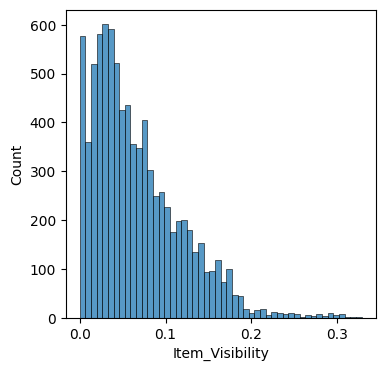

In [37]:
# Item Visibility:

plt.figure(figsize= (4,4))
sns.histplot(data= train_df, x= "Item_Visibility")
plt.show()

- Distribution for Item Visibility is Right Skewed.
- We can try Log / Square Root Transformations to make it Normal.

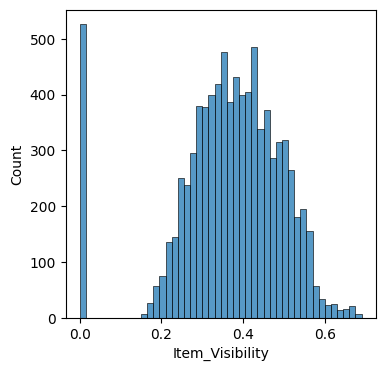

In [53]:
plt.figure(figsize= (4,4))
sns.histplot(x = train_df['Item_Visibility'].apply(np.cbrt))
plt.show()

In [54]:
# Updating Preprocessing Dictionary:

preprocessing_dict['Item_Visibility'] = {'transform': 'cbrt'}
preprocessing_dict

{'Item_Weight': {'imputer': 'mean'},
 'Outlet_Size': {'imputer': 'Outlet_Size_Imputer'},
 'Item_Visibility': {'transform': 'cbrt'}}

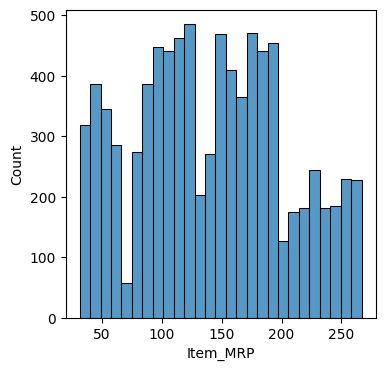

In [55]:
# Item MRP:

plt.figure(figsize= (4,4))
sns.histplot(data= train_df, x= "Item_MRP")
plt.show()

- No need for any transformations.

In [58]:
# Outlet Establishment Year:

train_df['Outlet_Establishment_Year']

0       1999
1       2009
2       1999
3       1998
4       1987
        ... 
8518    1987
8519    2002
8520    2004
8521    2009
8522    1997
Name: Outlet_Establishment_Year, Length: 8523, dtype: int64

- We will convert this to Outlet Age Feature and Drop The Original Column.

In [64]:
class Outlet_Age(BaseEstimator, TransformerMixin):

    def __init__(self, current_year = None):
        self.current_year = current_year or datetime.now().year

    def fit(self, X, y= None):
        return self # Nothing to learn

    def transfrom(self, X):
        X_ = X.copy()
        if 'Outlet_Establishment_Year' in X_.columns:
            X_['Outlet_Age'] = self.current_year - X_['Outlet_Establishment_Year']
            X_.drop('Outlet_Establishment_Year', axis= 1, inplace= True)

        return X_

In [66]:
# Updating Preprocessing Dictionary:
preprocessing_dict['Outlet_Establishment_Year'] = {'transform': 'Outlet_Age'}
preprocessing_dict

{'Item_Weight': {'imputer': 'mean'},
 'Outlet_Size': {'imputer': 'Outlet_Size_Imputer'},
 'Item_Visibility': {'transform': 'cbrt'},
 'Outlet_Establishment_Year': {'transform': 'Outlet_Age'}}

###### 2) For Categorical Features: